# 7장 실습 — 대리 경사와 BPTT로 SNN 학습

**Spiking Neural Networks 쿡북 with Python** · 7장 실습 노트북

완전연결 스파이킹 신경망을 MNIST로 **처음부터 학습**시킨다. 핵심은 발화의 비미분성을 우회하는 **대리 경사**와, 시간으로 펼친 네트워크를 학습하는 **BPTT**다.

### 학습 목표
- `surrogate.fast_sigmoid`로 대리 경사를 지정한다.
- 시간 스텝마다 출력을 모아 교차 엔트로피 손실을 정의한다.
- `loss.backward()`(BPTT)와 옵티마이저로 가중치를 학습시킨다.
- 학습 곡선과 정확도를 확인한다.

> 이 책의 실습 코드는 가독성을 위해 `if`문과 `try/except` 예외처리를 사용하지 않는다.

## 1. 설치와 임포트

In [1]:
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate          # 대리 경사 함수
from snntorch import utils              # 데이터 부분집합 등
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(42)
device = torch.device('cpu')          # 이 실습은 CPU로 진행
batch_size = 128

## 2. 데이터 준비 (MNIST)

MNIST를 불러오고, 빠른 실습을 위해 학습셋의 일부만 사용한다. `drop_last=True`로 마지막 배치를 버려 항상 같은 배치 크기를 유지한다.

In [2]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.Compose(
    [transforms.ToTensor(), 
     transforms.Normalize((0,), (1,))]
)
mnist_train = datasets.MNIST(
    '/tmp/data/mnist', 
    train=True, 
    download=True, 
    transform=transform
)
mnist_test = datasets.MNIST(
    '/tmp/data/mnist', 
    train=False, 
    download=True, 
    transform=transform
)

mnist_train = utils.data_subset(mnist_train, subset=20)   # 1/20만 사용

train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=True, drop_last=True)
print('학습 샘플 수:', len(mnist_train))

학습 샘플 수: 3000


## 3. 완전연결 SNN 정의 — 대리 경사 지정

입력 784 → 은닉 1000 → 출력 10 구조다. 각 `snn.Leaky`에 `spike_grad=surrogate.fast_sigmoid()`를 넘기면 순전파는 계단 함수, 역전파는 부드러운 대리 경사를 쓴다. `forward`는 `num_steps` 동안 순전파하며 출력 스파이크와 막전위를 시간 축으로 쌓아 반환한다.

In [3]:
num_inputs, num_hidden, num_outputs = 784, 1000, 10
num_steps = 25
beta = 0.95
spike_grad = surrogate.fast_sigmoid()   # 대리 경사

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()       # 은닉 막전위 초기화
        mem2 = self.lif2.init_leaky()       # 출력 막전위 초기화
        spk2_rec, mem2_rec = [], []
        # 같은 입력을 num_steps번 흘리며 막전위 누적
        for step in range(num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)
        return torch.stack(spk2_rec), torch.stack(mem2_rec)

net = Net().to(device)
print(net)

Net(
  (fc1): Linear(in_features=784, out_features=1000, bias=True)
  (lif1): Leaky()
  (fc2): Linear(in_features=1000, out_features=10, bias=True)
  (lif2): Leaky()
)


## 4. 손실과 옵티마이저

손실은 각 시간 스텝의 출력 막전위에 교차 엔트로피를 적용해 **합산**한다. 정답 클래스 뉴런의 막전위가 더 커지도록 유도한다.

In [4]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    net.parameters(), 
    lr=5e-4, 
    betas=(0.9, 0.999)
)

## 5. 학습 루프 (BPTT)

각 배치에서 순전파로 출력을 모으고, 시간 스텝별 손실을 더한 뒤 `backward()`를 부른다. 이 한 번의 호출이 시간으로 펼친 그래프 전체에 대해 **BPTT**를 수행한다. 진행 상황을 보기 위해 매 반복마다 손실과 정확도를 출력한다.

In [5]:
loss_hist = []
net.train()
for data, targets in train_loader:
    data = data.view(batch_size, -1).to(device)   # 이미지를 784 벡터로
    targets = targets.to(device)

    spk_rec, mem_rec = net(data)                  # 시간 전개 순전파

    loss_val = torch.zeros(1, device=device)
    # 시간 스텝마다 손실을 더한다
    for step in range(num_steps):
        loss_val = loss_val + loss_fn(mem_rec[step], targets)

    optimizer.zero_grad()
    loss_val.backward()        # BPTT
    optimizer.step()

    _, idx = spk_rec.sum(0).max(1)                # 누적 스파이크 최다 뉴런
    acc = (targets == idx).float().mean().item()
    loss_hist.append(loss_val.item())
    print(f'손실 {loss_val.item():.2f} | 배치 정확도 {acc*100:.1f}%')

손실 58.50 | 배치 정확도 8.6%
손실 50.61 | 배치 정확도 31.2%
손실 44.36 | 배치 정확도 66.4%
손실 44.96 | 배치 정확도 54.7%
손실 41.24 | 배치 정확도 70.3%
손실 40.79 | 배치 정확도 61.7%
손실 38.90 | 배치 정확도 68.0%
손실 34.64 | 배치 정확도 74.2%
손실 34.97 | 배치 정확도 78.1%
손실 32.44 | 배치 정확도 81.2%
손실 30.46 | 배치 정확도 78.1%
손실 29.63 | 배치 정확도 82.8%
손실 27.76 | 배치 정확도 84.4%
손실 26.85 | 배치 정확도 80.5%
손실 27.81 | 배치 정확도 81.2%
손실 23.63 | 배치 정확도 83.6%
손실 22.96 | 배치 정확도 84.4%
손실 22.82 | 배치 정확도 82.0%
손실 18.66 | 배치 정확도 85.9%
손실 21.74 | 배치 정확도 79.7%
손실 23.62 | 배치 정확도 80.5%
손실 16.60 | 배치 정확도 93.0%
손실 17.89 | 배치 정확도 83.6%


## 6. 학습 손실 곡선

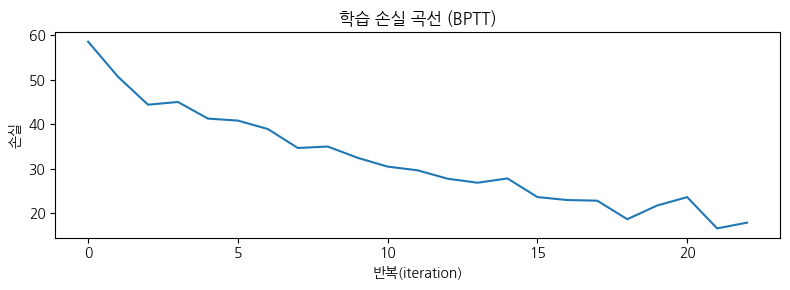

In [6]:
plt.figure(figsize=(8, 3))
plt.plot(loss_hist, color='tab:blue')
plt.xlabel('반복(iteration)'); plt.ylabel('손실')
plt.title('학습 손실 곡선 (BPTT)')
plt.tight_layout(); plt.show()

## 7. 테스트 정확도 평가

테스트셋 전체에 대해 누적 스파이크 기반 정확도를 계산한다. 평가 시에는 `torch.no_grad()`로 기울기 계산을 끈다.

In [7]:
def measure_accuracy(net, data_loader):
    total = 0
    correct = 0
    net.eval()
    with torch.no_grad():
        for data, targets in data_loader:
            data = data.view(batch_size, -1).to(device)
            targets = targets.to(device)
            spk_rec, _ = net(data)
            _, idx = spk_rec.sum(0).max(1)
            correct += (targets == idx).sum().item()
            total += targets.size(0)
    return correct / total

test_acc = measure_accuracy(net, test_loader)
print(f'테스트 정확도: {test_acc*100:.2f}%')

테스트 정확도: 85.10%


## 정리

- `surrogate.fast_sigmoid()`로 대리 경사를 지정해 발화의 비미분성을 우회한다.
- 시간 스텝별 출력 막전위에 교차 엔트로피를 더해 손실을 정의한다.
- `loss.backward()` 한 번이 시간 전개 그래프 전체에 BPTT를 수행한다.
- 더 높은 정확도를 원하면 `subset`을 줄이거나 에폭을 추가하면 된다.

다음 8장에서는 합성곱 층을 결합한 CSNN으로 같은 과제를 더 효율적으로 푼다.